imshow
i: 0, x_v: 0, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=0): 717.015
i: 0, x_v: 1, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=1): 717.658
i: 0, x_v: 2, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=2): 719.513
i: 0, x_v: 3, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=3): 720.319
i: 0, x_v: 4, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=4): 721.326
i: 0, x_v: 5, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=5): 721.677
i: 0, x_v: 6, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=6): 720.479
i: 0, x_v: 7, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=7): 720.088
i: 0, x_v: 8, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=8): 720.283
i: 0, x_v: 9, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=9): 719.448
i: 0, x_v: 10, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=10): 719.431
i: 0, x_v: 11, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=11): 719.129
i: 0, x_v: 12, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=12): 719.821
i: 0, x_v: 13, y_v: 0, Hour: 1.0
PWV value at (i=0, x_v=13): 720.834
i: 0, x_v: 14, y_v: 0, Hour: 1.0
PWV value at (

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


i: 14, x_v: 1127, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1127): 822.348
i: 14, x_v: 1128, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1128): 824.296
i: 14, x_v: 1129, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1129): 825.826
i: 14, x_v: 1130, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1130): 826.793
i: 14, x_v: 1131, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1131): 826.72
i: 14, x_v: 1132, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1132): 821.424
i: 14, x_v: 1133, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1133): 821.241
i: 14, x_v: 1134, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1134): 818.723
i: 14, x_v: 1135, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1135): 815.445
i: 14, x_v: 1136, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1136): 813.768
i: 14, x_v: 1137, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1137): 808.691
i: 14, x_v: 1138, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1138): 808.372
i: 14, x_v: 1139, y_v: 14, Hour: 19.0
PWV value at (i=14, x_v=1139): 806.28
i

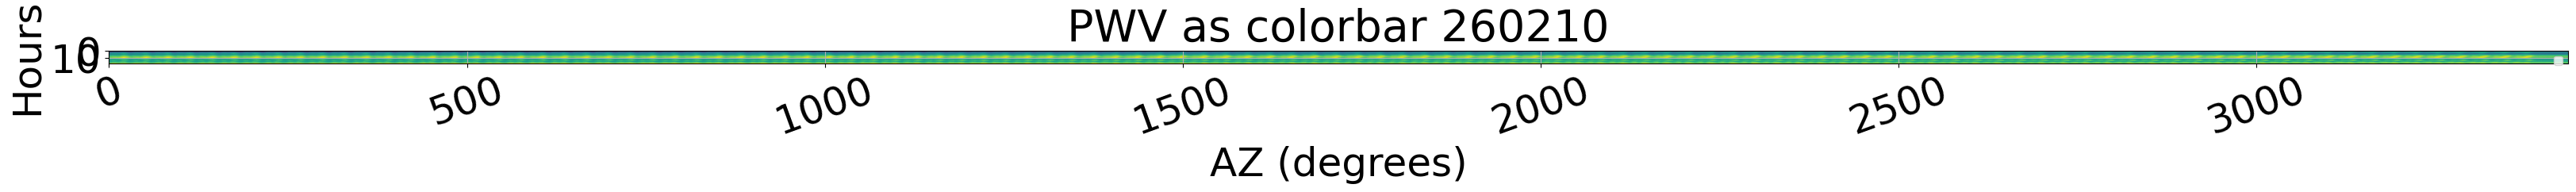

In [3]:
# improve version for the 1 hour section as y axis detail in sec in x axis
# use colorbar to show PWV vaules

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from metpy.units import units

seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')

TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []

for file in files:
    df = pd.read_csv(
        file,
        dtype={
            'DATE(YYYYMMDD)': str,
            'START TIME(HHMMSS.Microsec)': str,
            'PWV TOTAL zenith': str,
            'PWV TOTAL line-of-sight': str
        }
    )

    df['TIME'] = pd.to_datetime(
        df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'],
        format='%Y%m%d %H%M%S.%f',
        errors='coerce'
    )

    df = df.sort_values(by='TIME')

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '', regex=False).astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '', regex=False).astype(float)

    TIME.extend(df['TIME'].tolist())
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

TIME = pd.to_datetime(TIME, errors='coerce')

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
showAngle_df['Time'] = pd.to_datetime(showAngle_df['Time'], errors='coerce')
showAngle_df = showAngle_df.dropna(subset=['Time'])

if len(showAngle_df) != len(TIME) and len(TIME) > 0:
    showAngle_df = showAngle_df[showAngle_df['Time'].dt.date == TIME[0].date()]

showAngleTime = showAngle_df['Time'].tolist()
showAngleAZ = showAngle_df['AZ'].tolist()

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")

AZ_deg = [[]]
PWV_Zen = [[]]
scan_Times = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
            scan_Times[len(scan_Times)-1].append(showAngleTime[i])

        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            scan_Times.append([])

            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
            scan_Times[len(scan_Times)-1].append(showAngleTime[i])


np_PWV = np.zeros(( len(PWV_Zen), len(PWV_Zen[0]) ))

for i in range(len(PWV_Zen)):
    for j in range(len(PWV_Zen[0])):        
        np_PWV[i][j] = PWV_Zen[i][j]

fig, ax = plt.subplots(figsize=(40, 27))
im = ax.imshow(np_PWV)
print("imshow")

for i in (range(len(AZ_deg))): #len(AZ_deg)
    scan_hour = scan_Times[i][0].hour
    Hour = scan_hour * np.ones(len(AZ_deg[i]))  # Create an array of y-values for the current scan

    # ax.set_xticks(range(len(AZ_deg[i][0])), labels=AZ_deg[i], rotation=45, ha="right", rotation_mode="anchor")
    # ax.set_yticks(range(len(Hour[0])), labels=Hour)

    y_loc = i

    for x_v in range(len(AZ_deg[0])):

        print(f"i: {i}, x_v: {x_v}, y_v: {y_loc}, Hour: {Hour[0]}")

        z_v = np_PWV[y_loc, x_v]
        print(f"PWV value at (i={i}, x_v={x_v}): {z_v}")
        
        #text = ax.text(y_loc, x_v, z_v, ha="center", va="center", color="w")
    
    print(f"Finished scan {i}")
    
print("after for loop")

plt.title(f'PWV as colorbar {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('Hours', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
#handles, labels = plt.gca().get_legend_handles_labels()
plt.legend() #handles[::-1], labels[::-1], loc="best",fontsize=24,markerscale=3.5

plt.grid(alpha=1)
plt.show()
plt.close()


In [ ]:
"""for 2026/02/10 sec data
Make colorbar
try 0227
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob 
from metpy.units import units
from matplotlib import colors


seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
showAngleTime.extend(showAngle_df['Time'].tolist())
showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")

#!!!-----------------remove the [[]] for offset plot-------------------!!!

fig, ax1 = plt.subplots(figsize=(20, 10))

x_bins = 20
y_bins = 20

np_PWV = np.asarray(PWV_TOTAL_zenith)
print(np_PWV,np_PWV.shape)

while True:
    break

    np_AZ = np.asarray(showAngleAZ)
    H, xedges, yedges = np.histogram2d(np_AZ, np_PWV, bins=[x_bins, y_bins])

    im = ax1.imshow(
    H.T,                          # transpose so axes match
    origin="lower",
    aspect="auto",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    norm=colors.Normalize(vmin=1, vmax=600),
    cmap='Grays'
    )

    cb = fig.colorbar(im, ax=ax1)
    cb.set_label("Count in bin",fontsize=18)

    ax1.set_xlabel("AZ (degrees)", fontsize=18)
    ax1.set_ylabel("PWV (um)", fontsize=18)
    ax1.set_title("PWV vs AZ (counts image)", fontsize=20)

    plt.tight_layout()
    plt.show()
    plt.close()
    #break


    plt.figure(figsize=(20, 10))
    plt.scatter(np_AZ, np_PWV, s=10, c='blue', alpha=0.5)
    plt.show()



In [ ]:
"""for 2026/02/10 sec data
Make colorbar
error only plot once
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob 
from metpy.units import units
from matplotlib import colors


seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
showAngleTime.extend(showAngle_df['Time'].tolist())
showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))
save_arr = []
try:
    for i in range(len(showAngleTime)):
        save_arr.append(showAngleAZ[i])
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")


AZ_deg = [[]]
PWV_Zen = [[]]


for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

fig, ax1 = plt.subplots(figsize=(20, 10))

np_PWV_0 = np.asarray(PWV_Zen[0])
np_AZ_0 = np.asarray(AZ_deg[0])

print("PWV_0 shape: ", np_PWV_0.shape)
print("AZ_0 shape: ", np_AZ_0.shape)

x_bins = 10
y_bins = 10

H_0, xedges, yedges = np.histogram2d(np_AZ_0, np_PWV_0, bins=[x_bins, y_bins])
norm_0 = colors.Normalize(vmin=1, vmax=H_0.max())

for i in range(1): #len(PWV_Zen)
    print(i)
    np_PWV = np.asarray(PWV_Zen[i])
    np_AZ = np.asarray(AZ_deg[i])
    H, xedges, yedges = np.histogram2d(np_AZ, np_PWV, bins=[x_bins, y_bins])

    im = ax1.imshow(
    H.T,                          # transpose so axes match
    origin="lower",
    aspect="auto",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    norm=norm_0,
    cmap='Grays'
    )

    cb = fig.colorbar(im, ax=ax1)
    cb.set_label("Count in bin",fontsize=18)

    ax1.set_xlabel("AZ (degrees)", fontsize=18)
    ax1.set_ylabel("PWV (um)", fontsize=18)
    ax1.set_title("PWV vs AZ (scan 1 only)", fontsize=20)

    plt.tight_layout()
    plt.show()
    #plt.close()
    break





# notes!!!
which CMB data day bad or good?

In [ ]:
# AI suggestion version:

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from metpy.units import units

seasons = ['260209']
files = glob.glob('2602/0209Sec/time_pwv_2602_*.csv')

TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []

for file in files:
    df = pd.read_csv(
        file,
        dtype={
            'DATE(YYYYMMDD)': str,
            'START TIME(HHMMSS.Microsec)': str,
            'PWV TOTAL zenith': str,
            'PWV TOTAL line-of-sight': str
        }
    )

    df['TIME'] = pd.to_datetime(
        df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'],
        format='%Y%m%d %H%M%S.%f',
        errors='coerce'
    )

    df = df.sort_values(by='TIME')

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '', regex=False).astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '', regex=False).astype(float)

    TIME.extend(df['TIME'].tolist())
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

TIME = pd.to_datetime(TIME, errors='coerce')

showAngle_df = pd.read_csv('2602/showAngle260209.csv')
showAngle_df['Time'] = pd.to_datetime(showAngle_df['Time'], errors='coerce')
showAngle_df = showAngle_df.dropna(subset=['Time'])

if len(showAngle_df) != len(TIME) and len(TIME) > 0:
    showAngle_df = showAngle_df[showAngle_df['Time'].dt.date == TIME[0].date()]

showAngleTime = showAngle_df['Time'].tolist()
showAngleAZ = showAngle_df['AZ'].tolist()

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")

AZ_deg = [[]]
PWV_Zen = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k']
markers = ['o','o','o','o','o','o','o',
           '*','*','*','*','*','*','*',
           's','s','s','s','s','s','s']
offset_x = 0
offset_y = 0

plt.figure(figsize=(40, 27))

for i in (range(len(AZ_deg))): #len(AZ_deg)
    # print(f"len of AZ_deg[{i}] {len(AZ_deg[i])}, len of PWV_Zen[{i}] {len(PWV_Zen[i])}")
    plt.scatter([AZ+offset_x for AZ in AZ_deg[i][0:]], [PWV + offset_y for PWV in PWV_Zen[i][0:]], 
             marker=markers[i], color=colors[i], label=f'Scan{i} with offset at y {offset_y}',
             s=45,alpha=0.7)
    
    # x axis {offset_x} y {offset_y}
    offset_x += 40000
    offset_y += 0

plt.title(f'PWV Total Zenith Over AZ for {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('Total PWV Zenith (um)', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc="best",fontsize=24,markerscale=3.5)

plt.grid(alpha=1)
plt.show()
plt.close()


In [ ]:
"""for 2026/02/09 sec data
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import os

seasons = ['260209']
files = glob.glob('2602/0209Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist()) #!!!!!

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

TIME = pd.to_datetime(TIME, errors='coerce')
showAngle_df = pd.read_csv('2602/showAngle260209.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
# showAngleTime.extend(showAngle_df['Time'].tolist())
# showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")


if len(showAngleTime) != len(TIME):
    mask = (showAngle_df['Time'].dt.day == TIME[0].day)
    filtered_df = showAngle_df[mask]
showAngleTime = filtered_df['Time'].tolist()
showAngleAZ = filtered_df['AZ'].tolist()

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")


AZ_deg = [[]]
PWV_Zen = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k']
markers = ['o','o','o','o','o','o','o',
           '*','*','*','*','*','*','*',
           's','s','s','s','s','s','s']
offset_x = 0
offset_y = 0

plt.figure(figsize=(40, 27))

for i in (range(len(AZ_deg))): #len(AZ_deg)
    # print(f"len of AZ_deg[{i}] {len(AZ_deg[i])}, len of PWV_Zen[{i}] {len(PWV_Zen[i])}")
    plt.scatter([AZ+offset_x for AZ in AZ_deg[i][0:]], [PWV + offset_y for PWV in PWV_Zen[i][0:]], 
             marker=markers[i], color=colors[i], label=f'Scan{i} with offset at y {offset_y}',
             s=45,alpha=0.7)
    
    # x axis {offset_x} y {offset_y}
    offset_x += 40000
    offset_y += 0

plt.title(f'PWV Total Zenith Over AZ for {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('Total PWV Zenith (um)', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc="best",fontsize=24,markerscale=3.5)

plt.grid(alpha=1)
plt.show()
plt.close()




In [ ]:
"""for 2026/02/10 sec data
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import os

seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})

    # if df['START TIME(HHMMSS.Microsec)'][0] == '010136.217888':
    #     #print("Found missing time, adding it to the dataframe")
    #     # Create a new row as dictionary
    #     new_row = {
    #         "DATE(YYYYMMDD)": "20260210",
    #         "START TIME(HHMMSS.Microsec)": "010253.121565",
    #         "END TIME(HHMMSS.Microsec)": "010253.121565",
    #         "PWV TOTAL zenith": "729.18 um_pwv",
    #         "PWV TOTAL line-of-sight": "890.165 um_pwv",
    #         "Nscale_troposphere_h2o": 1.71789
    #     }

    #     # Append row
    #     df.loc[len(df)] = new_row

    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
showAngleTime.extend(showAngle_df['Time'].tolist())
showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")


AZ_deg = [[]]
PWV_Zen = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

delta_PWV_AZ_previous = [[]]
for i in range(len(PWV_Zen)):
    if i+1 < len(PWV_Zen) and len(PWV_Zen[i+1]) > 0:
        for j in range(len(PWV_Zen[0])-1): # give a constant length 
            if j < len(PWV_Zen[i+1]):
                delta_PWV_AZ_previous[i].append(PWV_Zen[i+1][j] - PWV_Zen[i][j])
        delta_PWV_AZ_previous.append([])

colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k', 
          'b', 'r', 'g', 'c', 'm', 'y', 'k']
offset = 0
plt.figure(figsize=(40/2, 27/2))

# print("AZ_deg length", len(AZ_deg))
# print("delta_PWV_AZ_previous length", len(delta_PWV_AZ_previous))
# print("len for 1st [] of AZ",len(AZ_deg[0]))
# print("len for 1st delta PWV", len(delta_PWV_AZ_previous[0]))

for i in range(len(delta_PWV_AZ_previous)):
    if len(delta_PWV_AZ_previous[i]) > 0:
        print(f"work for i={i}, len of delta_PWV_AZ_previous[i] {len(delta_PWV_AZ_previous[i])}, len of AZ_deg[i] {len(AZ_deg[i])}")
        plt.scatter(AZ_deg[i][:len(PWV_Zen[0])-1], [offset + delta for delta in delta_PWV_AZ_previous[i]], marker='o', color=colors[i % len(colors)])
        offset += 0
    else:
        print("Error",i)

plt.title(f'delta_PWV Over AZ for {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('delta_PWV (um)', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
plt.grid()
plt.show()
plt.close()

